# Punto 5 (e) — Introducción conceptual a Machine Learning

## *"¿Este va a pagar?"*

**Unidad III — Estadística Descriptiva · Diplomatura en Data Analytics (UNNE)**

En la notebook 05, con una muestra dijimos algo de la población. Machine Learning hace
el mismo salto, pero hacia adelante: **con los casos que ya vimos, decir algo de casos
que todavía no vimos**. Las dos cosas son *generalizar*, y las dos fallan por los mismos
motivos.

**El caso de la clase:** una financiera tiene 5.000 préstamos del año pasado y sabe quién
pagó y quién no. Mañana alguien nuevo pide un préstamo. ¿Se lo damos?

> **Los datos son inventados** (`data/raw/creditos_sinteticos.csv`). No salen de ningún
> banco: los fabricamos con una regla conocida más ruido (el script está en
> `data/generar_creditos_sinteticos.py`). Eso es una ventaja: como sabemos cómo se
> hicieron, podemos comprobar qué aprende el modelo y qué se inventa.

Mismo formato de siempre: **qué es → dónde sirve → ⚠️ forzando el concepto**.

## 0 · Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 110)

df = pd.read_csv("../data/raw/creditos_sinteticos.csv")
df["cuota_sobre_ingreso"] = df["cuota"] / df["ingreso_mensual"]
print(f"{df.shape[0]:,} préstamos listos")

5,000 préstamos listos


## 1 · La tabla: filas, features y target

**Qué es.** Es la misma tabla de siempre, con nombres nuevos:

| en ML se dice | qué es acá |
|---|---|
| **fila** u observación | una persona que pidió un préstamo |
| **features** (variables predictoras) | lo que sabemos **antes** de decidir: edad, sueldo, cuota, antigüedad, atrasos, consultas |
| **target** (lo que queremos predecir) | `pago`: 1 si pagó, 0 si no |

**Dónde sirve.** Para decidir el tipo de problema. Es el mismo razonamiento del punto 1:
**el tipo de variable manda**.

| si el target es… | el problema se llama | ejemplo |
|---|---|---|
| una categoría | **clasificación** | ¿paga o no paga? |
| un número | **regresión** | ¿cuánto límite de tarjeta le doy? |
| no hay target | **no supervisado** | agrupar clientes por cómo usan la tarjeta |

In [2]:
print(df.head().to_string())
print()
print(f"pagaron: {df['pago'].mean():.1%}")

   edad  ingreso_mensual   cuota  antiguedad_laboral  atrasos_12m  consultas_recientes dia_solicitud  pago  cuota_sobre_ingreso
0    59          1529000  498000                 1.9            0                    1        jueves     1             0.325703
1    28           667000   28000                 7.6            0                    1        martes     1             0.041979
2    21           728000   62000                 2.7            0                    1       viernes     1             0.085165
3    49           378000   89000                 8.1            1                    0       viernes     1             0.235450
4    36          1287000  200000                 3.5            0                    0         lunes     1             0.155400

pagaron: 90.5%


## 2 · La regla a mano (programación clásica)

**Qué es.** Antes del ML, un analista escribía la regla: *"se aprueba si no tuvo atrasos
y la cuota es hasta el 30% del sueldo"*. Es programación clásica:

```
   regla + datos  →  respuesta          (programación clásica)
   datos + respuestas  →  regla         (machine learning)
```

In [3]:
regla = ((df["atrasos_12m"] == 0) & (df["cuota_sobre_ingreso"] <= 0.30)).astype(int)

print(f"la regla aprueba al {regla.mean():.0%} de los que piden")
print(f"y acierta en el {(regla == df['pago']).mean():.1%} de los casos")

la regla aprueba al 69% de los que piden
y acierta en el 77.6% de los casos


#### ⚠️ Forzando el concepto: la trampa del 90%

¿77% de aciertos es bueno? Antes de festejar hay que compararlo con **el modelo más
tonto posible**: aprobar a todos, sin mirar nada. Eso se llama **baseline**.

In [4]:
aprobar_a_todos = np.ones(len(df), dtype=int)
print(f"baseline (aprobar a todos) acierta: {(aprobar_a_todos == df['pago']).mean():.1%}")
print(f"regla del analista acierta:         {(regla == df['pago']).mean():.1%}")
print()
print(pd.crosstab(regla.map({1: "aprueba", 0: "rechaza"}),
                  df["pago"].map({1: "pagó", 0: "no pagó"}),
                  rownames=["la regla"], colnames=["lo que pasó"]).to_string())

baseline (aprobar a todos) acierta: 90.5%
regla del analista acierta:         77.6%

lo que pasó  no pagó  pagó
la regla                  
aprueba            9  3417
rechaza          464  1110


> **Aprobar a todos acierta más que el analista**, porque 9 de cada 10 pagan: con
> decir siempre "paga" ya acertás 9 de cada 10. El porcentaje de aciertos, solo, engaña.
>
> Pero mirá la tabla: el analista frena a casi todos los que no pagan, a cambio de
> rechazar a más de mil personas que sí habrían pagado. Los dos tipos de error no
> cuestan lo mismo, y eso lo retomamos en la sección 6.

## 3 · Separar para poder probar: train y test

**Qué es.** Antes de entrenar nada, se aparta una parte de los datos (acá el 30%) y **no
se toca**. El modelo aprende con el resto (*train*) y después se lo evalúa con lo que
nunca vio (*test*).

**Dónde sirve.** Es la versión ML de la pregunta de la notebook 05: *¿esto vale fuera de
mis datos?* Si evaluás con los mismos casos con los que aprendió, estás tomando examen
con las preguntas que el alumno ya tenía resueltas.

El modelo sólo entiende números, así que `dia_solicitud` se convierte en cinco columnas
de 0 y 1 (`pd.get_dummies`).

In [5]:
FEATURES = ["edad", "ingreso_mensual", "cuota", "cuota_sobre_ingreso",
            "antiguedad_laboral", "atrasos_12m", "consultas_recientes", "dia_solicitud"]

X = pd.get_dummies(df[FEATURES], columns=["dia_solicitud"], dtype=int)
y = df["pago"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f"train: {len(X_train):,} préstamos   ← con estos aprende")
print(f"test:  {len(X_test):,} préstamos   ← con estos lo evaluamos")

train: 3,500 préstamos   ← con estos aprende
test:  1,500 préstamos   ← con estos lo evaluamos


## 4 · Que la máquina encuentre la regla

**Qué es.** Un **árbol de decisión** hace preguntas de sí o no, una detrás de otra, y
elige solo cuáles hacer y dónde cortar. Le pedimos como máximo 3 preguntas seguidas
(`max_depth=3`), para que la regla se pueda leer.

Todo el ML con `scikit-learn` usa los mismos tres verbos:

| verbo | qué hace |
|---|---|
| `train_test_split` | separa los datos (sección 3) |
| `.fit(X, y)` | aprende la regla a partir de los ejemplos |
| `.predict(X)` | aplica la regla a casos nuevos |

In [6]:
arbol = DecisionTreeClassifier(max_depth=3, random_state=42)
arbol.fit(X_train, y_train)

print(export_text(arbol, feature_names=list(X.columns), decimals=2))

|--- cuota_sobre_ingreso <= 0.37
|   |--- atrasos_12m <= 0.50
|   |   |--- cuota_sobre_ingreso <= 0.34
|   |   |   |--- class: 1
|   |   |--- cuota_sobre_ingreso >  0.34
|   |   |   |--- class: 1
|   |--- atrasos_12m >  0.50
|   |   |--- cuota_sobre_ingreso <= 0.21
|   |   |   |--- class: 1
|   |   |--- cuota_sobre_ingreso >  0.21
|   |   |   |--- class: 0
|--- cuota_sobre_ingreso >  0.37
|   |--- atrasos_12m <= 0.50
|   |   |--- cuota_sobre_ingreso <= 0.48
|   |   |   |--- class: 1
|   |   |--- cuota_sobre_ingreso >  0.48
|   |   |   |--- class: 0
|   |--- atrasos_12m >  0.50
|   |   |--- antiguedad_laboral <= 9.45
|   |   |   |--- class: 0
|   |   |--- antiguedad_laboral >  9.45
|   |   |   |--- class: 0



**Cómo se lee** (`class: 1` quiere decir "predice que paga"): la máquina encontró sola
las mismas dos cosas que miraba el analista, **la cuota sobre el sueldo y los atrasos**,
pero con cortes más finos. A grandes rasgos: si la cuota es hasta el 37% del sueldo y no
tuvo atrasos, paga; con atrasos, sólo si la cuota es chica; si la cuota es muy alta, no
paga. Y no usó el día de la semana para nada.

Ahora, la prueba de verdad: los casos que nunca vio.

In [7]:
pred = arbol.predict(X_test)

print(f"baseline (aprobar a todos): {y_test.mean():.1%}")
print(f"árbol de 3 preguntas:       {(pred == y_test).mean():.1%}")

baseline (aprobar a todos): 90.5%
árbol de 3 preguntas:       94.6%


## 5 · ⚠️ Forzando el concepto: el que memoriza

¿Y si lo dejamos hacer todas las preguntas que quiera? Un árbol sin límite puede
separar **cada** préstamo de train en su propia hoja: acierta el 100%… en train.

In [8]:
memorion = DecisionTreeClassifier(random_state=42)   # sin max_depth: sin límite
memorion.fit(X_train, y_train)

print(f"{'':22}{'train':>8}{'test':>8}")
for nombre, m in [("árbol de 3 preguntas", arbol), ("árbol sin límite", memorion)]:
    print(f"{nombre:22}{m.score(X_train, y_train):>8.1%}{m.score(X_test, y_test):>8.1%}")
print(f"{'baseline':22}{'':>8}{y_test.mean():>8.1%}")
print()
print(f"el árbol sin límite tiene {memorion.get_n_leaves()} hojas; el de 3 preguntas, {arbol.get_n_leaves()}")

                         train    test
árbol de 3 preguntas     94.7%   94.6%
árbol sin límite        100.0%   92.3%
baseline                         90.5%

el árbol sin límite tiene 163 hojas; el de 3 preguntas, 8


> **El que memoriza saca 10 en la práctica y peor nota en el examen.** Eso es
> **sobreajuste**: aprendió las casualidades de estos 3.500 casos, no el patrón.

¿Qué casualidades? Nosotros sabemos que el día de la semana **no influye en nada**:
fabricamos los datos así. Miremos cuánto lo usa cada árbol.

In [9]:
def peso_del_dia(modelo):
    imp = pd.Series(modelo.feature_importances_, index=X.columns)
    return imp[imp.index.str.startswith("dia_solicitud")].sum()

print(f"árbol de 3 preguntas: el día pesa {peso_del_dia(arbol):.1%} en sus decisiones")
print(f"árbol sin límite:     el día pesa {peso_del_dia(memorion):.1%} en sus decisiones")

árbol de 3 preguntas: el día pesa 0.0% en sus decisiones
árbol sin límite:     el día pesa 3.8% en sus decisiones


> Es la **regla del martes** de la actividad *"Sé el modelo"*: con 8 tarjetas, el día de
> la semana parecía explicarlo todo. El árbol sin límite hace lo mismo a escala: usa algo
> que no tiene nada que ver, porque en train *casualmente* ayudaba.

Veamos todo el recorrido, de 1 a 20 preguntas:

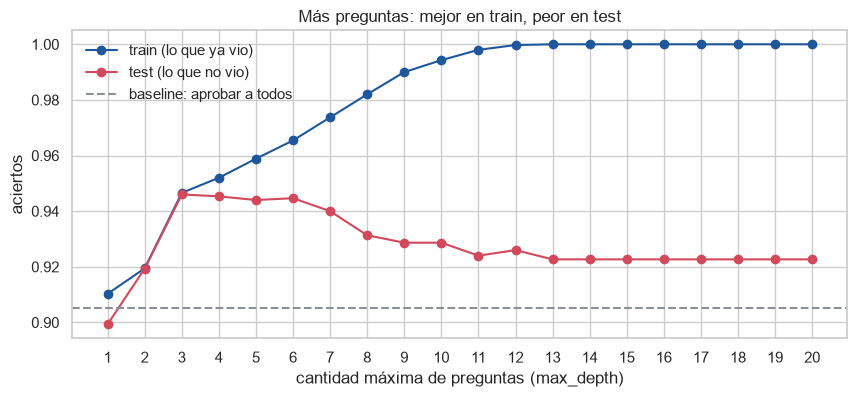

In [10]:
profundidades = range(1, 21)
res = []
for d in profundidades:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    res.append((m.score(X_train, y_train), m.score(X_test, y_test)))
res = np.array(res)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(profundidades, res[:, 0], marker="o", color="#1E579B", label="train (lo que ya vio)")
ax.plot(profundidades, res[:, 1], marker="o", color="#D1495B", label="test (lo que no vio)")
ax.axhline(y_test.mean(), color="#8A8F98", ls="--", label="baseline: aprobar a todos")
ax.set_xlabel("cantidad máxima de preguntas (max_depth)")
ax.set_ylabel("aciertos")
ax.set_xticks(list(profundidades))
ax.legend(frameon=False)
ax.set_title("Más preguntas: mejor en train, peor en test")
plt.show()

> **La curva roja sube, llega a un techo y baja.** Hasta ahí el modelo aprende el
> patrón; de ahí en más aprende ruido. La distancia entre las dos curvas es lo que el
> modelo memorizó. Por eso **nunca** se evalúa un modelo con los datos con los que
> aprendió.

## 6 · El score y el umbral: elegir qué error duele más

**Qué es.** En vez de "paga / no paga", el modelo puede dar una **probabilidad** de que
pague. Multiplicada por 1.000, es un **score**: el número que ves cuando una billetera
virtual te dice que "no calificás". La financiera decide un **umbral**: aprueba a
quien supere, por ejemplo, 500.

**Dónde sirve.** Mover el umbral cambia un error por otro:

In [11]:
score = (arbol.predict_proba(X_test)[:, 1] * 1000).round()

filas = []
for umbral in [0, 300, 500, 700, 950]:
    aprueba = score >= umbral
    filas.append({
        "umbral": umbral,
        "aprobados": f"{aprueba.mean():.0%}",
        "morosos aprobados": int((aprueba & (y_test == 0)).sum()),
        "buenos rechazados": int((~aprueba & (y_test == 1)).sum()),
        "aciertos": f"{(aprueba.astype(int) == y_test).mean():.1%}",
    })
print(pd.DataFrame(filas).set_index("umbral").to_string())

       aprobados  morosos aprobados  buenos rechazados aciertos
umbral                                                         
0           100%                142                  0    90.5%
300          97%                 94                  4    93.5%
500          91%                 45                 36    94.6%
700          85%                 24                110    91.1%
950          73%                  6                265    81.9%


Pensalo como el juicio de la notebook 05, con **H0 = "esta persona va a pagar"** (la
presunción de inocencia) y "rechazar el crédito" como la condena:

| error | quién lo paga | en la notebook 05 era… |
|---|---|---|
| **rechazar a alguien que sí pagaba** (bueno rechazado) | la financiera pierde un cliente, y la persona se queda sin crédito | el **error tipo I**: condenar a un inocente |
| **aprobar a alguien que no paga** (moroso aprobado) | la financiera pierde plata | el **error tipo II**: absolver a un culpable |

> **Es el mismo tire y afloje que α en el contraste de hipótesis:** subir el umbral
> baja un error y sube el otro, y no hay umbral que los baje a los dos. Elegirlo no es
> una decisión estadística: es de negocio (¿cuánto cuesta un moroso contra un cliente
> perdido?) y también ética.

## 7 · Dónde falla (y todo es inferencia otra vez)

Nada de esto se ve en la exactitud del test, y todo tiene que ver con lo que vimos en
la notebook 05:

1. **La muestra que no representa.** La financiera sólo sabe si pagaron **los que
   aprobó**. De los que rechazó nunca va a saber si hubieran pagado. El modelo aprende
   de una cucharada sacada siempre del mismo lado de la olla.
2. **El mundo cambia.** Un modelo entrenado antes de una crisis o de un salto
   inflacionario aprende un mundo que ya no existe. Por eso los modelos se monitorean y
   se reentrenan.
3. **Sesgo.** Si el modelo usa el código postal, puede terminar castigando a un barrio
   entero por lo que hicieron otros. Correlación no es causalidad (punto 3).

**La diferencia de fondo:**

| | estadística | machine learning |
|---|---|---|
| pregunta | *¿por qué la gente no paga?* | *¿esta persona va a pagar?* |
| busca | **explicar** | **predecir** |
| se evalúa con | intervalos y contrastes | aciertos en datos que no vio |

## 8 · Lo que hay que llevarse

1. **ML es aprender la regla a partir de ejemplos** (datos + respuestas → regla), en vez de escribirla a mano.
2. **El tipo de target decide el problema:** categoría → clasificación; número → regresión; sin target → no supervisado.
3. **Siempre hay que comparar contra un baseline.** Con 9 de cada 10 que pagan, "aprobar a todos" ya acierta el 90%.
4. **Train y test:** se evalúa con lo que el modelo nunca vio. Es la pregunta de la inferencia con otra ropa.
5. **Sobreajuste:** el que memoriza es perfecto en train y peor en test, y usa cosas que no tienen nada que ver (el día de la semana).
6. **El umbral reparte los errores.** No se pueden bajar los dos a la vez; cuál duele más lo decide el negocio, no el modelo.
7. **Un modelo hereda los problemas de su muestra:** si los datos no representan, o el mundo cambia, el modelo falla aunque el test diga que anda bien.